# Experiment: Pathway Recovery Downstream Experiment



In [5]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.pathway_recovery as pathway_recovery
importlib.reload(pathway_recovery)

run_pathway_recovery = pathway_recovery.run_pathway_recovery

repo_root


WindowsPath('e:/CODE/trishift')

## Parameters

Choose one input mode for this notebook.

- Use `trishift_runs_manifest` or `trishift_runs` to compare custom TriShift result directories.
- Leave both empty to run the default cross-method comparison with `models`.


In [6]:
dataset = "norman"
split_ids = [1]
truth_deg_mode = "scanpy"
pred_deg_mode = "scanpy"
enrichment_mode = "run_if_available"  # export_only | run_if_available | disabled
enrichment_library = "Reactome_2022"
space = "full_gene"  # auto | full_gene | deg
n_degs = 100
out_root = repo_root / "artifacts" / "analysis" / "pathway_recovery_downstream_experiment"

# Optional: compare custom TriShift result directories instead of the default model list.
# 1) If you already have a manifest, set trishift_runs_manifest to that file.
# trishift_runs_manifest = repo_root / "artifacts" / "ablation" / "adamson" / "<timestamp>_state_targeted_ablation" / "pathway_trishift_runs.json"
# 2) If you do not want to use a manifest, define trishift_runs directly.
trishift_runs_manifest = ""
trishift_runs = []
# trishift_runs = [
#     {"label": "state", "result_dir": str(repo_root / "artifacts" / "results" / "adamson" / "state"), "variant_tag": "nearest"},
#     {"label": "best", "result_dir": str(repo_root / "artifacts" / "results" / "adamson" / "best"), "variant_tag": "nearest"},
# ]

if trishift_runs_manifest:
    trishift_runs = pathway_recovery._load_trishift_runs_manifest(trishift_runs_manifest)

if trishift_runs:
    result = run_pathway_recovery(
        dataset=dataset,
        split_ids=split_ids,
        truth_deg_mode=truth_deg_mode,
        pred_deg_mode=pred_deg_mode,
        enrichment_mode=enrichment_mode,
        enrichment_library=enrichment_library,
        space=space,
        n_degs=n_degs,
        out_root=out_root,
        trishift_runs=trishift_runs,
    )
else:
    models = ["trishift_nearest", "scouter", "gears", "genepert"]
    result = run_pathway_recovery(
        dataset=dataset,
        models=models,
        split_ids=split_ids,
        truth_deg_mode=truth_deg_mode,
        pred_deg_mode=pred_deg_mode,
        enrichment_mode=enrichment_mode,
        enrichment_library=enrichment_library,
        space=space,
        n_degs=n_degs,
        out_root=out_root,
    )

print(f"out_dir: {result['out_dir']}")


d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModifi

out_dir: E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment


## Tables

这里先看 per-condition metrics、gene list 汇总以及 pathway overlap 表。


In [7]:
display(result["metric_summary_df"])
display(result["per_condition_df"].head(30))
display(result["gene_lists_df"].head(30))
display(result["overlap_df"].head(30))
display(result["corr_df"].head(30))
display(result["hitk_df"].head(30))


,model_name,top10_overlap,top10_jaccard,combined_score_pearson,combined_score_spearman,hit_at_1,hit_at_3,hit_at_5,hit_at_10
0,genepert,1.828571,0.103524,0.48749,0.344048,0.0,0.342857,0.685714,0.885714
1,scouter,0.000000,0.000000,NaN,NaN,0.0,0.000000,0.000000,0.000000
2,trishift,0.021277,0.001120,NaN,NaN,0.0,0.000000,0.000000,0.021277


,model_name,dataset,split_id,condition,focus_key,pkl_path,deg_top_k,space_used,truth_deg_mode_used,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,precision_at_20,recall_at_20,truth_deg_count,pred_deg_count,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum,model_request
0,trishift,norman,1,AHR+FEV,1:AHR+FEV,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.959705,0.090466,37.924892,trishift_nearest
1,trishift,norman,1,AHR+KLF1,1:AHR+KLF1,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.986828,0.547527,19.219678,trishift_nearest
2,trishift,norman,1,BAK1+ctrl,1:BAK1+ctrl,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.996436,0.915456,11.261595,trishift_nearest
3,trishift,norman,1,BCL2L11+TGFBR2,1:BCL2L11+TGFBR2,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.989031,0.717384,13.890020,trishift_nearest
4,trishift,norman,1,C19orf26+TGFBR2,1:C19orf26+TGFBR2,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.979244,0.565562,22.823597,trishift_nearest
5,trishift,norman,1,C3orf72+FOXL2,1:C3orf72+FOXL2,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.979613,0.467056,27.643542,trishift_nearest
6,trishift,norman,1,CDKN1A+CDKN1C,1:CDKN1A+CDKN1C,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.985630,0.567541,17.122132,trishift_nearest
7,trishift,norman,1,CDKN1A+ctrl,1:CDKN1A+ctrl,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,0,0.000000,0.00,0.00,100,100,0.991696,0.728957,15.899959,trishift_nearest
8,trishift,norman,1,CEBPA+KLF1,1:CEBPA+KLF1,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,1,0.005025,0.01,0.01,100,100,0.895846,0.046018,40.671392,trishift_nearest
9,trishift,norman,1,CEBPA+ctrl,1:CEBPA+ctrl,E:\CODE\trishift\artifacts\results\norman\tris...,100,full_gene,scanpy,scanpy_rank,1,0.005025,0.01,0.01,100,100,0.839341,0.040804,55.185074,trishift_nearest


,model_name,dataset,split_id,condition,focus_key,list_type,rank,gene,deg_top_k,space_used,truth_deg_mode_used,pred_deg_mode_used,model_request
0,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,1,PERM1,100,full_gene,scanpy,scanpy_rank,trishift_nearest
1,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,2,TMPRSS2,100,full_gene,scanpy,scanpy_rank,trishift_nearest
2,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,3,PLA2G2A,100,full_gene,scanpy,scanpy_rank,trishift_nearest
3,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,4,LINC01252,100,full_gene,scanpy,scanpy_rank,trishift_nearest
4,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,5,RP11-421F16.3,100,full_gene,scanpy,scanpy_rank,trishift_nearest
5,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,6,RP11-630C16.2,100,full_gene,scanpy,scanpy_rank,trishift_nearest
6,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,7,RP11-474P2.4,100,full_gene,scanpy,scanpy_rank,trishift_nearest
7,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,8,PRAP1,100,full_gene,scanpy,scanpy_rank,trishift_nearest
8,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,9,RP11-500G22.4,100,full_gene,scanpy,scanpy_rank,trishift_nearest
9,trishift,norman,1,AHR+FEV,1:AHR+FEV,pred_deg20,10,PLPP4,100,full_gene,scanpy,scanpy_rank,trishift_nearest


,model_name,dataset,split_id,condition,top10_truth_terms,top10_pred_terms,top10_overlap,top10_jaccard
0,trishift,norman,1,AHR+FEV,10,10,0,0.000000
1,trishift,norman,1,AHR+KLF1,10,10,0,0.000000
2,trishift,norman,1,BAK1+ctrl,10,10,0,0.000000
3,trishift,norman,1,BCL2L11+TGFBR2,10,10,0,0.000000
4,trishift,norman,1,C19orf26+TGFBR2,10,10,0,0.000000
5,trishift,norman,1,C3orf72+FOXL2,10,10,0,0.000000
6,trishift,norman,1,CDKN1A+CDKN1C,10,10,0,0.000000
7,trishift,norman,1,CDKN1A+ctrl,10,10,0,0.000000
8,trishift,norman,1,CEBPA+KLF1,10,10,0,0.000000
9,trishift,norman,1,CEBPA+ctrl,10,10,1,0.052632


,model_name,dataset,split_id,condition,n_matched_terms,combined_score_pearson,combined_score_spearman
0,trishift,norman,1,AHR+FEV,0,NaN,NaN
1,trishift,norman,1,AHR+KLF1,0,NaN,NaN
2,trishift,norman,1,BAK1+ctrl,0,NaN,NaN
3,trishift,norman,1,BCL2L11+TGFBR2,0,NaN,NaN
4,trishift,norman,1,C19orf26+TGFBR2,0,NaN,NaN
5,trishift,norman,1,C3orf72+FOXL2,0,NaN,NaN
6,trishift,norman,1,CDKN1A+CDKN1C,0,NaN,NaN
7,trishift,norman,1,CDKN1A+ctrl,0,NaN,NaN
8,trishift,norman,1,CEBPA+KLF1,1,NaN,NaN
9,trishift,norman,1,CEBPA+ctrl,1,NaN,NaN


,model_name,dataset,split_id,condition,hit_at_1,hit_at_3,hit_at_5,hit_at_10
0,trishift,norman,1,AHR+FEV,0.0,0.0,0.0,0.0
1,trishift,norman,1,AHR+KLF1,0.0,0.0,0.0,0.0
2,trishift,norman,1,BAK1+ctrl,0.0,0.0,0.0,0.0
3,trishift,norman,1,BCL2L11+TGFBR2,0.0,0.0,0.0,0.0
4,trishift,norman,1,C19orf26+TGFBR2,0.0,0.0,0.0,0.0
5,trishift,norman,1,C3orf72+FOXL2,0.0,0.0,0.0,0.0
6,trishift,norman,1,CDKN1A+CDKN1C,0.0,0.0,0.0,0.0
7,trishift,norman,1,CDKN1A+ctrl,0.0,0.0,0.0,0.0
8,trishift,norman,1,CEBPA+KLF1,0.0,0.0,0.0,0.0
9,trishift,norman,1,CEBPA+ctrl,0.0,0.0,0.0,1.0


## Artifacts

如果启用了 enrichment，这里会出现真正的 pathway enrichment 结果；`export_only` 下更多是结果骨架和 DEG-level 汇总。


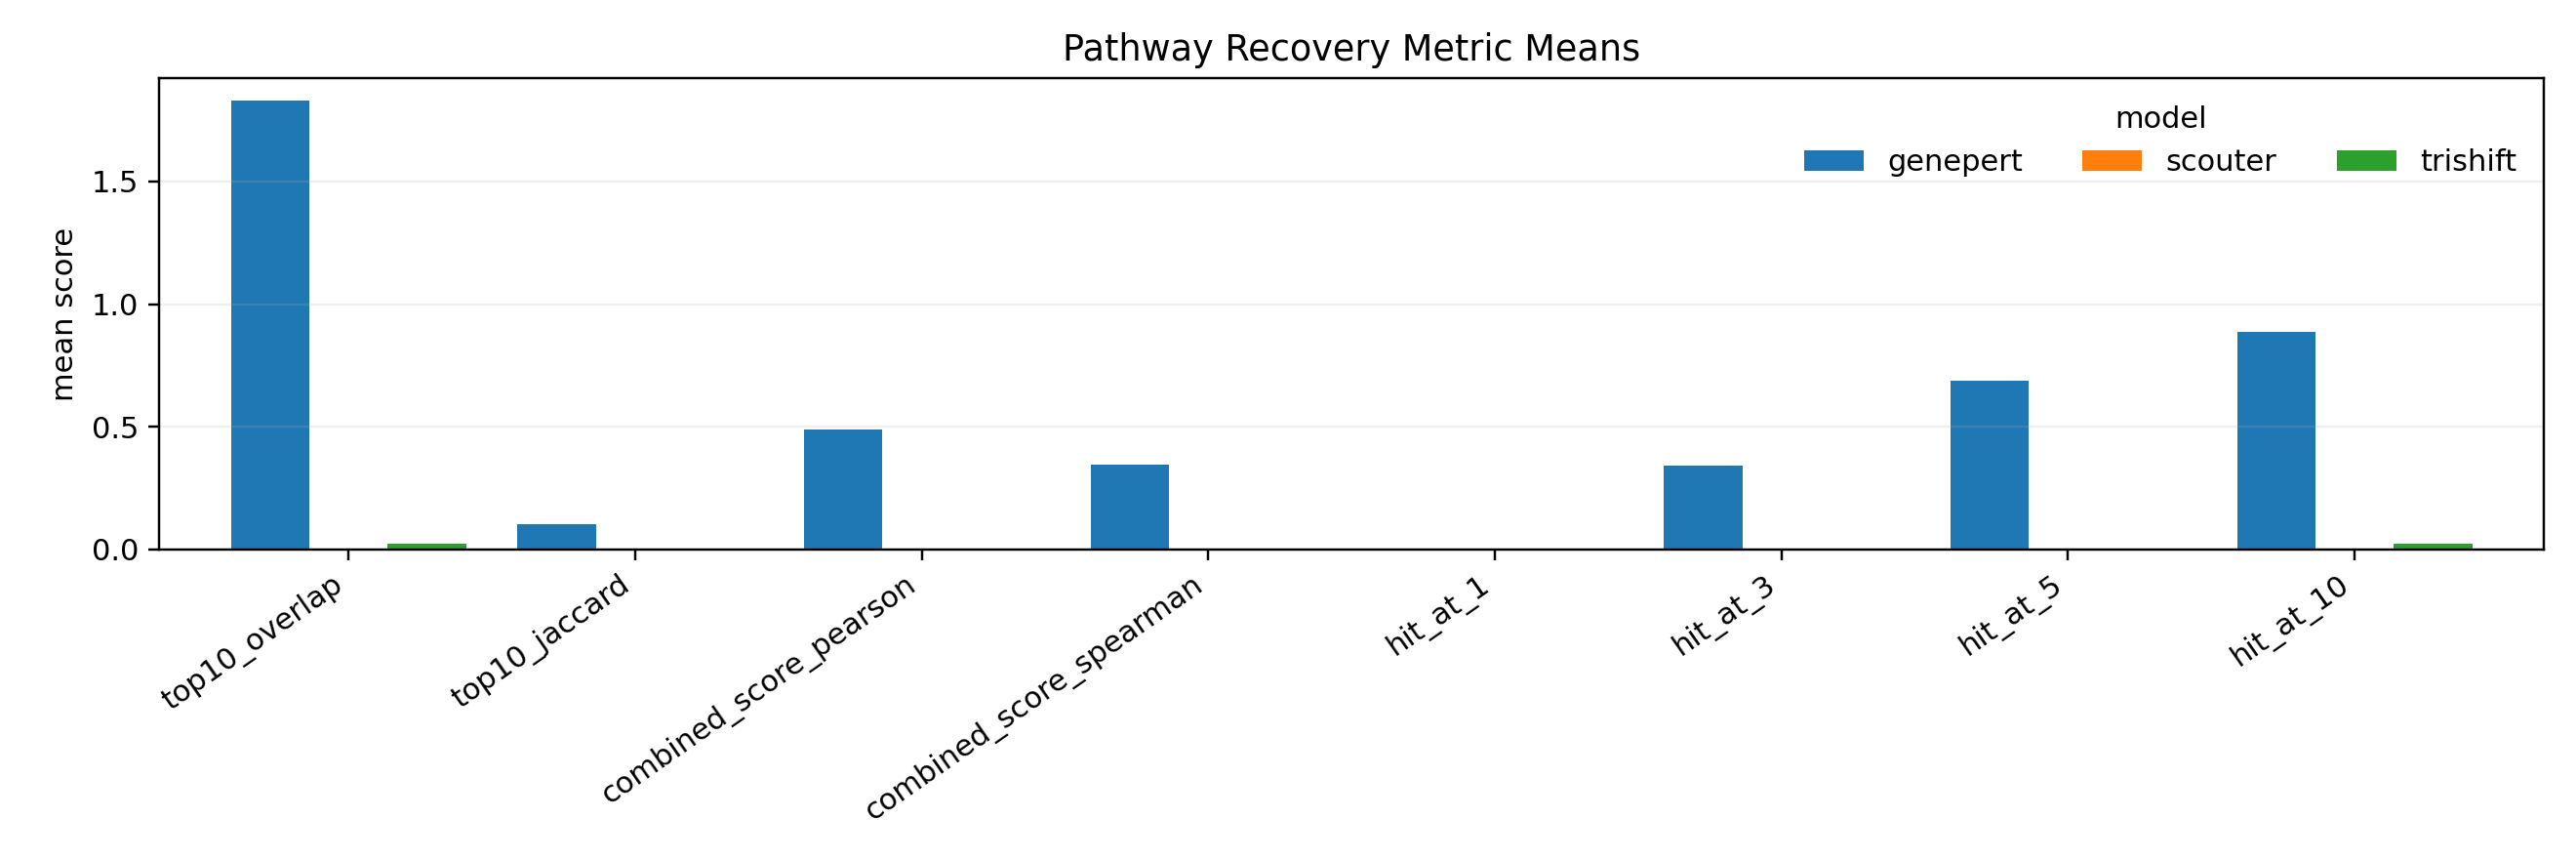

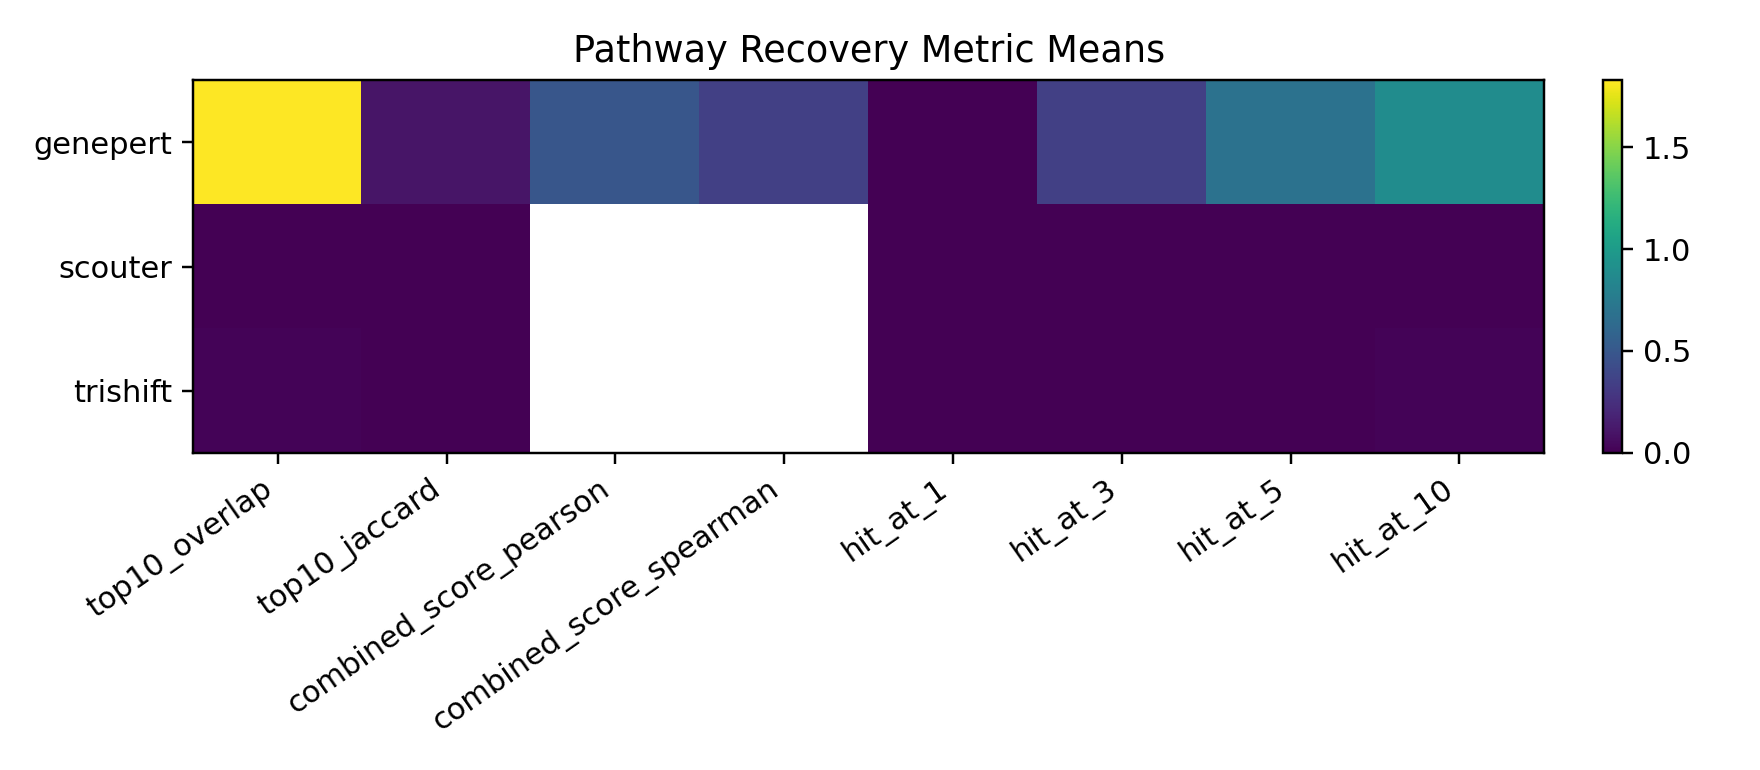

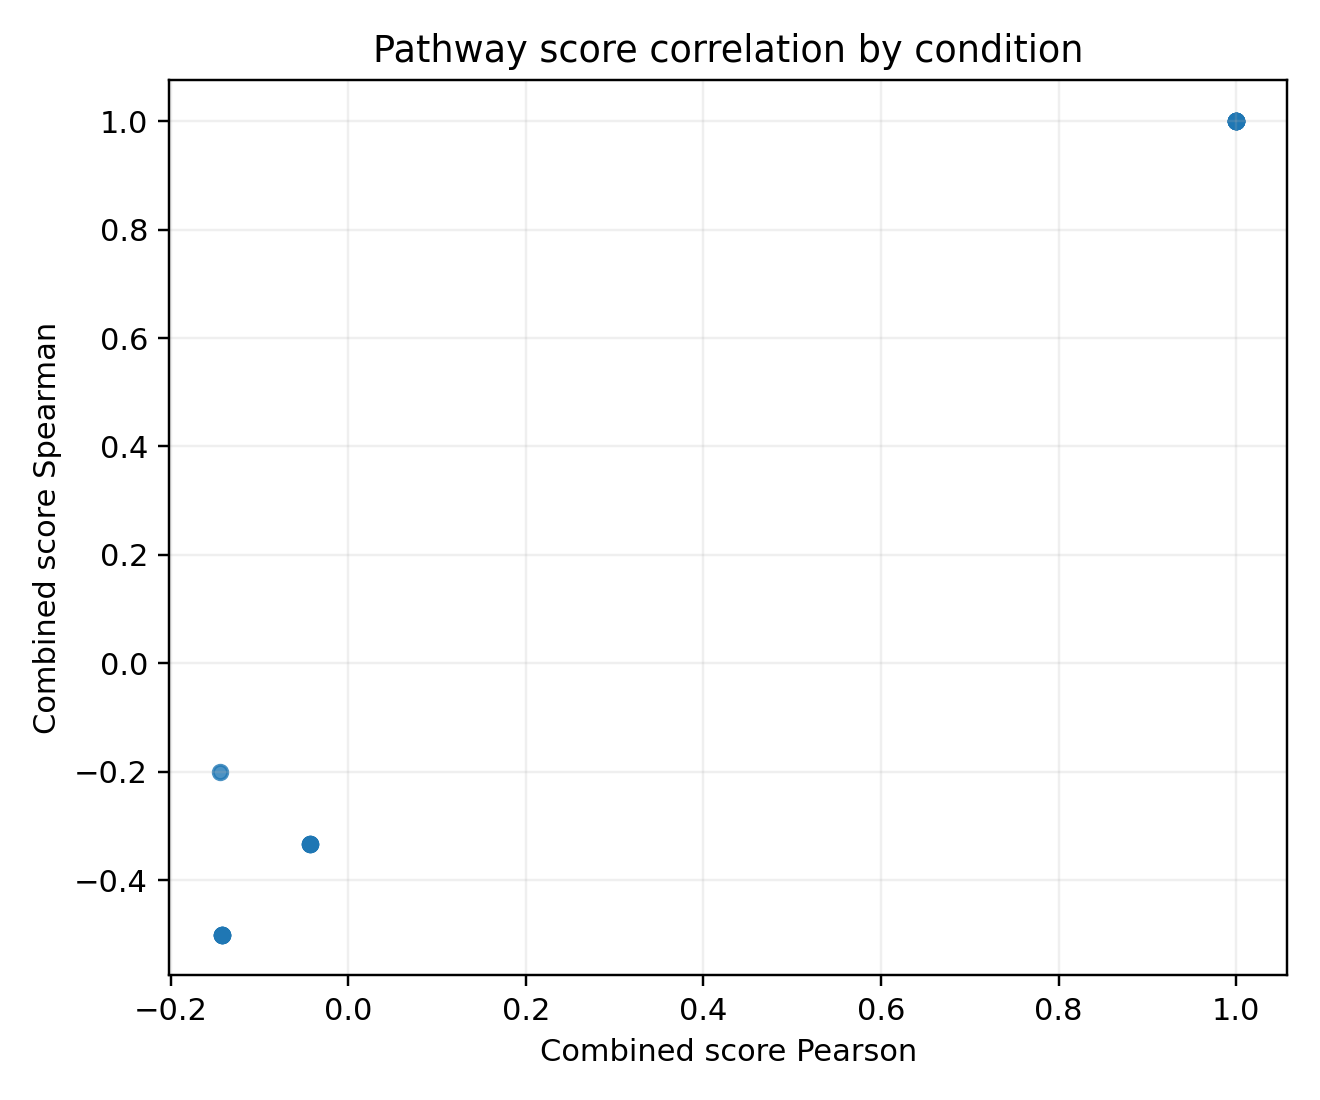

E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\deg20_per_condition_all.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\deg_gene_lists_all.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\pathway_enrichment_all.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\pathway_overlap_summary.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\pathway_nes_correlation.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\pathway_hitk_summary.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\pathway_metric_means.csv
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\pathway_metric_barplot.png
E:\CODE\trishift\artifacts\analysis\pathway_recovery_downstream_experiment\run_meta.json


In [8]:
out_dir = Path(result["out_dir"])
display(Image(filename=str(out_dir / "pathway_metric_barplot.png")))
display(Image(filename=str(out_dir / "pathway_metric_heatmap.png")))
display(Image(filename=str(out_dir / "pathway_nes_scatter.png")))

for path in [
    out_dir / "deg20_per_condition_all.csv",
    out_dir / "deg_gene_lists_all.csv",
    out_dir / "pathway_enrichment_all.csv",
    out_dir / "pathway_overlap_summary.csv",
    out_dir / "pathway_nes_correlation.csv",
    out_dir / "pathway_hitk_summary.csv",
    out_dir / "pathway_metric_means.csv",
    out_dir / "pathway_metric_barplot.png",
    out_dir / "run_meta.json",
]:
    print(path)
